<a href="https://colab.research.google.com/github/isil-ada/cifar10-multi-CNN-benchmark/blob/main/notebook_05_model5_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# YZM304 Derin Öğrenme – Proje 2
## Model 5: Tam CNN vs Hibrit Modeller — Karşılaştırma
**Bu notebook:**  
- Aynı `.npy` özellik dosyalarıyla **Random Forest** eğitir (Model 5A)  
- SVM'yi tekrar çalıştırır (Model 5B = Model 4)  
- Tam CNN (Model 2) ile karşılaştırır  
- Tüm projeyi özetleyen grafikler ve tablolar üretir  
> **Ön koşul:** `notebook_02`, `notebook_03`, `notebook_04` çalıştırılmış olmalı.

In [1]:
import torch, torch.nn as nn
import torchvision, torchvision.transforms as transforms
import numpy as np, matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)
import time

torch.manual_seed(42); np.random.seed(42)
DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASSES = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')
print(f'Cihaz: {DEVICE}')

Cihaz: cuda


In [2]:
# ── .npy Dosyalarını Yükle ─────────────────────────────────────────────────────
print('Özellik dosyaları yükleniyor...')
X_train = np.load('features_train.npy')
y_train = np.load('labels_train.npy')
X_test  = np.load('features_test.npy')
y_test  = np.load('labels_test.npy')

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}  | y_test : {y_test.shape}')

Özellik dosyaları yükleniyor...
X_train: (50000, 512) | y_train: (50000,)
X_test : (10000, 512)  | y_test : (10000,)


In [3]:
# ── Model 5A: CNN Features → Random Forest ────────────────────────────────────
# RandomForest mesafe tabanlı değil → normalizasyon gerekmez
print('\nRandom Forest eğitimi başlıyor (n_estimators=300)...')
t0 = time.time()
rf = RandomForestClassifier(n_estimators=300, max_depth=None,
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_acc   = accuracy_score(y_test, rf_preds) * 100
print(f'RF eğitim süresi: {time.time()-t0:.1f}s | Doğruluk: {rf_acc:.2f}%')
print(classification_report(y_test, rf_preds, target_names=CLASSES))


Random Forest eğitimi başlıyor (n_estimators=300)...
RF eğitim süresi: 114.6s | Doğruluk: 77.99%
              precision    recall  f1-score   support

       plane       0.77      0.82      0.80      1000
         car       0.89      0.89      0.89      1000
        bird       0.70      0.68      0.69      1000
         cat       0.60      0.59      0.60      1000
        deer       0.76      0.76      0.76      1000
         dog       0.71      0.68      0.69      1000
        frog       0.81      0.84      0.83      1000
       horse       0.81      0.81      0.81      1000
        ship       0.87      0.86      0.87      1000
       truck       0.85      0.87      0.86      1000

    accuracy                           0.78     10000
   macro avg       0.78      0.78      0.78     10000
weighted avg       0.78      0.78      0.78     10000



In [4]:
# ── Model 5B: CNN Features → SVM (Model 4 tekrar) ────────────────────────────
scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

print('SVM eğitimi başlıyor...')
t0  = time.time()
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(X_tr_sc, y_train)
svm_preds = svm.predict(X_te_sc)
svm_acc   = accuracy_score(y_test, svm_preds) * 100
print(f'SVM eğitim süresi: {time.time()-t0:.1f}s | Doğruluk: {svm_acc:.2f}%')

SVM eğitimi başlıyor...
SVM eğitim süresi: 443.9s | Doğruluk: 79.35%


In [5]:
# ── Önceki Model Sonuçlarını Yükle ────────────────────────────────────────────
def load_acc(fname):
    try:
        d = np.load(fname, allow_pickle=True).item()
        return float(d.get('best_acc', d.get('svm_acc', 0)))
    except:
        return None

m1_acc = load_acc('model1_results.npy')
m2_acc = load_acc('model2_results.npy')
m3_acc = load_acc('model3_results.npy')

print(f'Model 1 (LeNet5)         : {m1_acc:.2f}%' if m1_acc else 'Model 1: yüklenemedi')
print(f'Model 2 (BN+Drop)        : {m2_acc:.2f}%' if m2_acc else 'Model 2: yüklenemedi')
print(f'Model 3 (VGG11)          : {m3_acc:.2f}%' if m3_acc else 'Model 3: yüklenemedi')
print(f'Model 4 (CNN+SVM)        : {svm_acc:.2f}%')
print(f'Model 5A (CNN+RF)        : {rf_acc:.2f}%')

Model 1 (LeNet5)         : 79.67%
Model 2 (BN+Drop)        : 79.34%
Model 3 (VGG11)          : 87.13%
Model 4 (CNN+SVM)        : 79.35%
Model 5A (CNN+RF)        : 77.99%


In [6]:
# ── Genel Karşılaştırma Tablosu ───────────────────────────────────────────────
print('\n' + '='*55)
print(f'  {"Model":<30} {"Doğruluk":>12}')
print('='*55)
rows = [
    ('Model 1: LeNet-5 Benzeri CNN', m1_acc),
    ('Model 2: CNN + BN + Dropout',  m2_acc),
    ('Model 3: VGG11 (pretrained=F)',m3_acc),
    ('Model 4: CNN + SVM (Hibrit)',  svm_acc),
    ('Model 5A: CNN + RF (Hibrit)',  rf_acc),
]
for name, acc in rows:
    val = f'{acc:.2f}%' if acc else 'N/A'
    print(f'  {name:<30} {val:>12}')
print('='*55)


  Model                              Doğruluk
  Model 1: LeNet-5 Benzeri CNN         79.67%
  Model 2: CNN + BN + Dropout          79.34%
  Model 3: VGG11 (pretrained=F)        87.13%
  Model 4: CNN + SVM (Hibrit)          79.35%
  Model 5A: CNN + RF (Hibrit)          77.99%


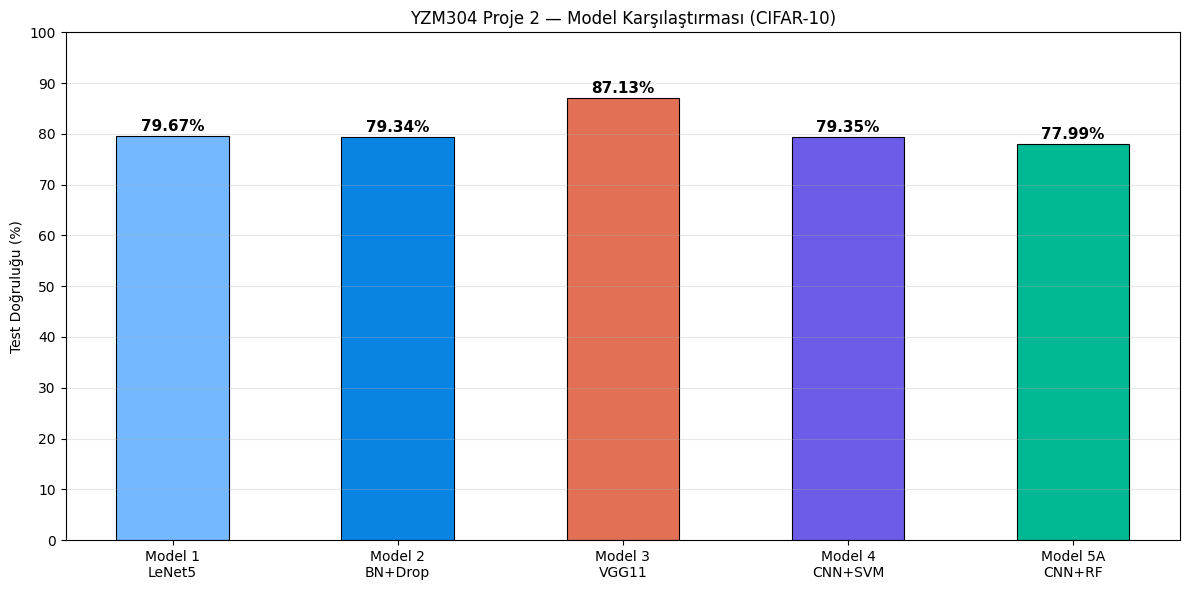

In [7]:
# ── Bar Karşılaştırma Grafiği ──────────────────────────────────────────────────
bar_names = ['Model 1\nLeNet5', 'Model 2\nBN+Drop',
             'Model 3\nVGG11', 'Model 4\nCNN+SVM', 'Model 5A\nCNN+RF']
bar_accs  = [m1_acc or 0, m2_acc or 0, m3_acc or 0, svm_acc, rf_acc]
bar_colors= ['#74b9ff','#0984e3','#e17055','#6c5ce7','#00b894']

fig, ax = plt.subplots(figsize=(12,6))
bars = ax.bar(bar_names, bar_accs, color=bar_colors, edgecolor='black', linewidth=0.8, width=0.5)
for bar, acc in zip(bars, bar_accs):
    if acc > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set(title='YZM304 Proje 2 — Model Karşılaştırması (CIFAR-10)',
       ylabel='Test Doğruluğu (%)', ylim=(0, 100))
ax.set_yticks(range(0, 101, 10)); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('model_comparison.png', dpi=150); plt.show()

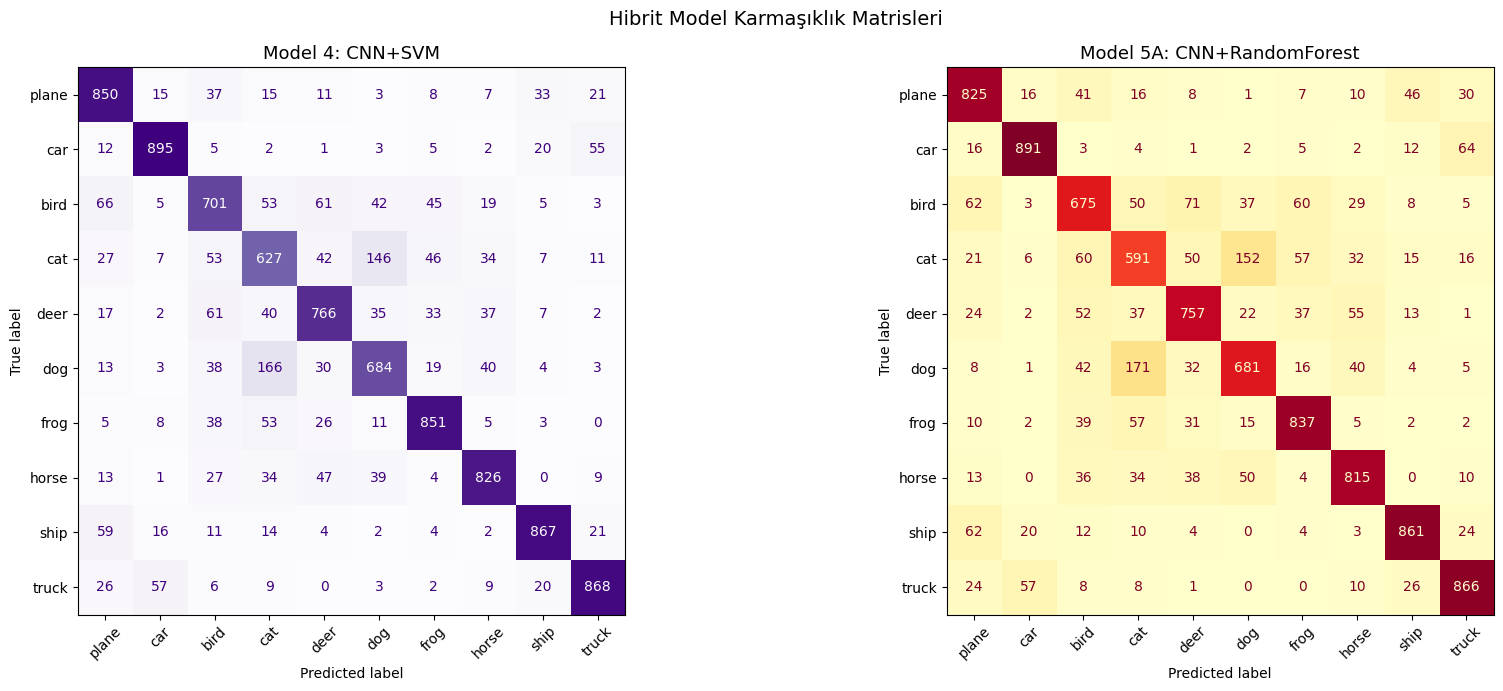

In [8]:
# ── Karmaşıklık Matrisleri (SVM & RF) ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18,7))
for ax, preds, title, cmap in zip(
    axes,
    [svm_preds, rf_preds],
    ['Model 4: CNN+SVM', 'Model 5A: CNN+RandomForest'],
    ['Purples', 'YlOrRd']
):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(
        ax=ax, cmap=cmap, colorbar=False, xticks_rotation=45)
    ax.set_title(title, fontsize=13)
plt.suptitle('Hibrit Model Karmaşıklık Matrisleri', fontsize=14)
plt.tight_layout(); plt.savefig('model45_confusion.png', dpi=150); plt.show()

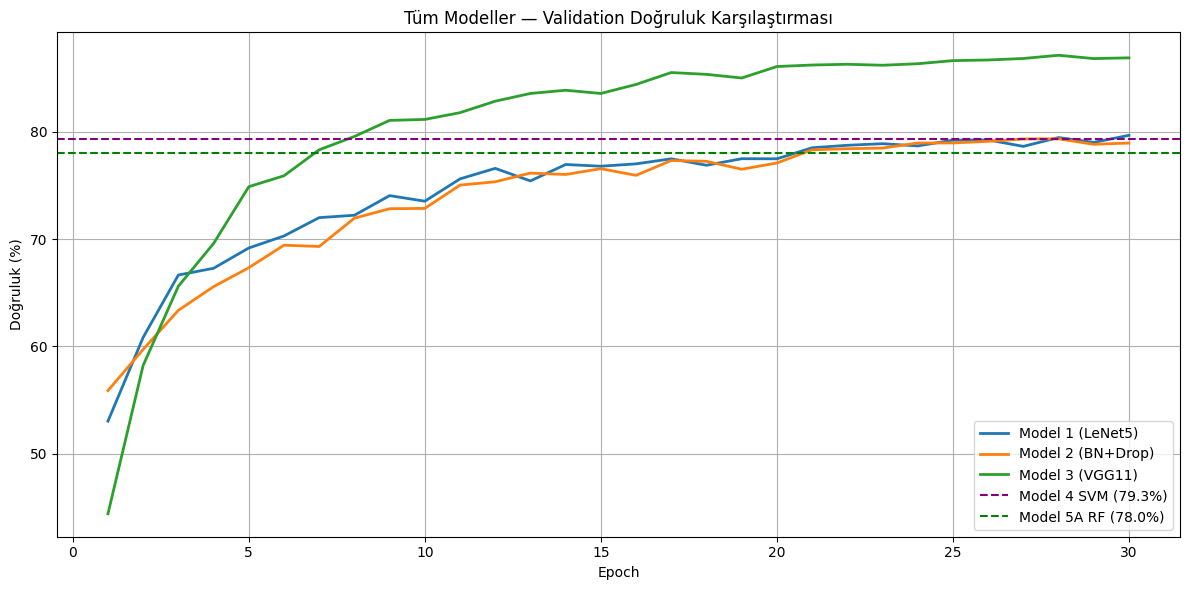

In [9]:
# ── Loss Eğrisi Karşılaştırması (Model 1 vs 2 vs 3) ──────────────────────────
def load_hist(fname, key):
    try:
        d = np.load(fname, allow_pickle=True).item()
        return d['history'][key]
    except:
        return None

m1_vl = load_hist('model1_results.npy','va')
m2_vl = load_hist('model2_results.npy','va')
m3_vl = load_hist('model3_results.npy','va')

if m1_vl and m2_vl and m3_vl:
    ep_r = range(1, len(m1_vl)+1)
    fig, ax = plt.subplots(figsize=(12,6))
    ax.plot(ep_r, m1_vl, label='Model 1 (LeNet5)', linewidth=2)
    ax.plot(ep_r, m2_vl, label='Model 2 (BN+Drop)', linewidth=2)
    ax.plot(range(1,len(m3_vl)+1), m3_vl, label='Model 3 (VGG11)', linewidth=2)
    ax.axhline(svm_acc, color='purple', linestyle='--', label=f'Model 4 SVM ({svm_acc:.1f}%)')
    ax.axhline(rf_acc,  color='green',  linestyle='--', label=f'Model 5A RF ({rf_acc:.1f}%)')
    ax.set(title='Tüm Modeller — Validation Doğruluk Karşılaştırması',
           xlabel='Epoch', ylabel='Doğruluk (%)')
    ax.legend(); ax.grid()
    plt.tight_layout(); plt.savefig('all_models_val_acc.png', dpi=150); plt.show()
else:
    print('Tüm model sonuç dosyaları bulunamadı. Önceki notebookları çalıştırın.')

In [10]:
# ── Proje Özeti ───────────────────────────────────────────────────────────────
print('\n' + '='*60)
print('  YZM304 Proje 2 — Genel Özet')
print('='*60)
print('  Veri Seti : CIFAR-10 (50K eğitim / 10K test / 10 sınıf)')
print()
for name, acc in rows:
    if acc:
        bar = '█' * int(acc // 5)
        print(f'  {name:<32} {bar} {acc:.2f}%')
print('='*60)
best_name, best_acc_val = max(rows, key=lambda x: x[1] or 0)
print(f'\n  En Yüksek Doğruluk: {best_name} → {best_acc_val:.2f}%')
print('='*60)


  YZM304 Proje 2 — Genel Özet
  Veri Seti : CIFAR-10 (50K eğitim / 10K test / 10 sınıf)

  Model 1: LeNet-5 Benzeri CNN     ███████████████ 79.67%
  Model 2: CNN + BN + Dropout      ███████████████ 79.34%
  Model 3: VGG11 (pretrained=F)    █████████████████ 87.13%
  Model 4: CNN + SVM (Hibrit)      ███████████████ 79.35%
  Model 5A: CNN + RF (Hibrit)      ███████████████ 77.99%

  En Yüksek Doğruluk: Model 3: VGG11 (pretrained=F) → 87.13%
